## 1. Linear Activation Function
* Definition: An activation function where the output is directly proportional to the input ($f(x) = cx$).
* Use Cases:
    * Regression tasks at the output layer; basic linear data mapping.
* Pros:
    * Computationally cheap and simple to compute.
    * Allows the network to produce unbounded output ranges.
* Cons:
    * The derivative is constant, meaning stacking multiple linear layers collapses into a single linear transformation.
    * Cannot learn complex, non-linear patterns.

## 2. Sigmoid Activation Function
* Definition: An S-shaped function that maps any real-valued number into a range between 0 and 1 ($f(x) = \frac{1}{1 + e^{-x}}$).
* Use Cases:
    * Binary classification output layers (to output probabilities).
* Pros:
    * Smooth gradient, preventing jumps in output values.
    * Output values have a clear probabilistic interpretation ($0$ to $1$).
* Cons:
    * Suffers from the vanishing gradient problem for very high or low inputs.
    * Outputs are not zero-centered.

## 3. Tanh (Hyperbolic Tangent) Activation Function
* Definition: An S-shaped function that maps input values to a range between -1 and 1 ($f(x) = \tanh(x)$).
* Use Cases:
    * Hidden layers of neural networks, recurrent neural networks (RNNs/LSTMs).
* Pros:
    * Zero-centered, making optimization and convergence easier compared to the Sigmoid function.
* Cons:
    * Still suffers from the vanishing gradient problem for extreme positive or negative input values.

## 4. ReLU (Rectified Linear Unit)
* Definition: A piecewise linear function that outputs the input directly if it is positive, otherwise it outputs zero ($f(x) = \max(0, x)$).
* Use Cases:
    * Default standard activation function for hidden layers in deep neural networks and CNNs.
* Pros:
    * Computationally efficient (requires only thresholding at zero).
    * Mitigates the vanishing gradient problem for positive inputs.
* Cons:
    * "Dying ReLU" problem: Neurons can permanently die and output zero for all inputs if large negative gradients push them out of action.

## 5. Leaky ReLU
* Definition: A variation of ReLU that allows a small, non-zero gradient when the input is negative ($f(x) = \max(\alpha x, x)$ where $\alpha$ is a small constant).
* Use Cases:
    * Deep networks where dying ReLU issues hinder model training.
* Pros:
    * Solves the dying ReLU problem by keeping negative gradients alive.
* Cons:
    * Performance can be inconsistent across different tasks; introduces an extra hyperparameter ($\alpha$) to tune.

## 6. ELU (Exponential Linear Unit)
* Definition: Uses a logarithmic curve for negative inputs to push the mean activation closer to zero ($f(x) = x$ if $x > 0$ else $\alpha(e^x - 1)$).
* Use Cases:
    * Deep networks aiming for faster learning and higher noise robustness.
* Pros:
    * Brings mean activations closer to zero, accelerating learning convergence.
    * Avoids the dying ReLU problem smoothly.
* Cons:
    * Computationally heavier due to exponential operations.

## 7. GELU (Gaussian Error Linear Unit)
* Definition: Weights inputs by their value, scaled by the cumulative distribution function of the standard normal distribution.
* Use Cases:
    * State-of-the-art Transformer models (e.g., BERT, GPT architectures).
* Pros:
    * Smooth, non-monotonic function that performs exceptionally well in modern natural language processing and computer vision transformers.
* Cons:
    * Computationally more expensive than standard ReLU.

## 8. Swish
* Definition: A smooth, non-monotonic activation function discovered via automated architecture search ($f(x) = x \cdot \text{sigmoid}(\beta x)$).
* Use Cases:
    * Deep convolutional networks and advanced multi-layer architectures.
* Pros:
    * Often outperforms ReLU on deeper models due to its smooth non-monotonicity.
* Cons:
    * Computationally demanding because of the embedded sigmoid calculation.

## 9. Softmax
* Definition: Generalizes the logistic function to multiple dimensions, converting raw output scores (logits) into a probability distribution that sums to 1.
* Use Cases:
    * Output layer for multi-class classification problems.
* Pros:
    * Provides clear, interpretable class probabilities.
* Cons:
    * Sensitive to extreme outlier logits; expensive to compute for massive output spaces.

### Visualizing Popular Activation Functions
The code below visualizes and compares the curves of activation functions.

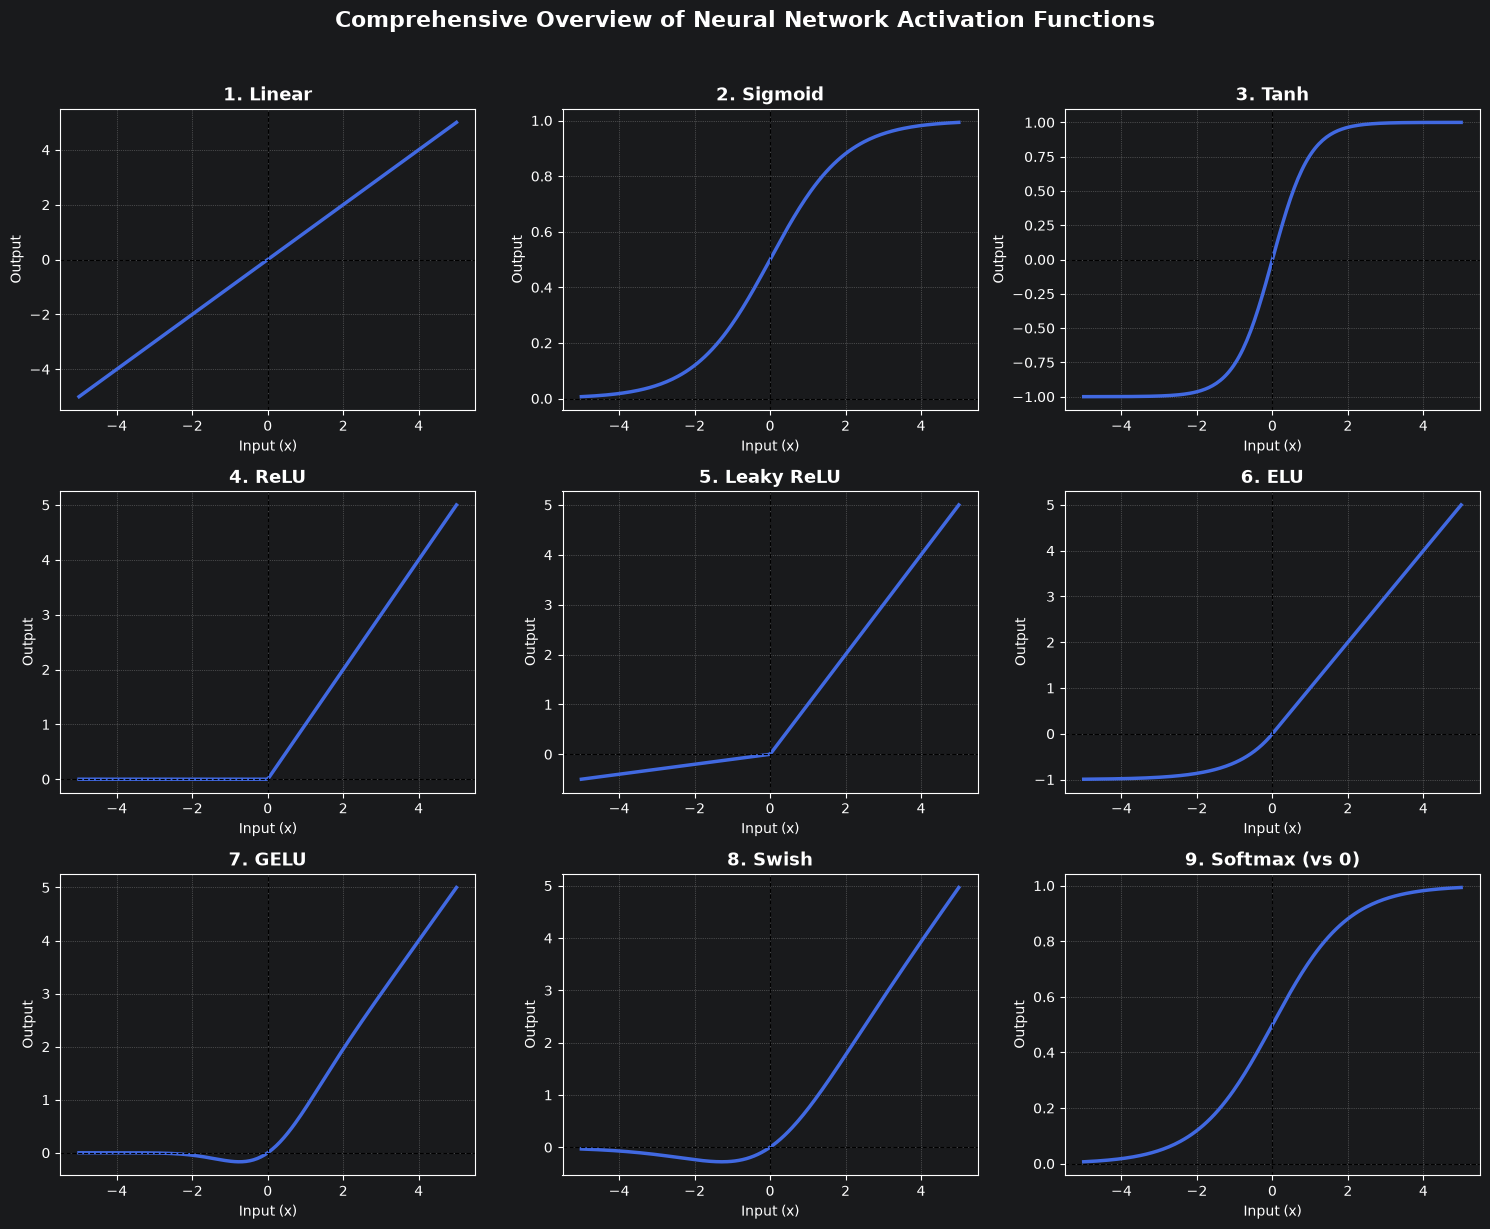

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

# 1. Define all 9 activation functions
def linear(x):
    return x

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.1):
    return np.where(x > 0, x, x * alpha)

def elu(x, alpha=1.0):
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))

def gelu(x):
    return 0.5 * x * (1 + erf(x / np.sqrt(2)))

def swish(x):
    return x * (1 / (1 + np.exp(-x)))

def softmax_scalar(x):
    # Visualizing Softmax via a 2-element vector [x, 0] mapped to probabilities
    exp_x = np.exp(x)
    exp_zero = np.exp(0)
    return exp_x / (exp_x + exp_zero)

# 2. Generate input range
x = np.linspace(-5, 5, 200)

# Dictionary containing names and computed outputs
activations = {
    "1. Linear": linear(x),
    "2. Sigmoid": sigmoid(x),
    "3. Tanh": tanh(x),
    "4. ReLU": relu(x),
    "5. Leaky ReLU": leaky_relu(x),
    "6. ELU": elu(x),
    "7. GELU": gelu(x),
    "8. Swish": swish(x),
    "9. Softmax (vs 0)": softmax_scalar(x)
}

# 3. Create a 3x3 grid plot for comprehensive visualization
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, (name, y) in enumerate(activations.items()):
    axes[i].plot(x, y, color='royalblue', linewidth=2.5)
    axes[i].set_title(name, fontsize=13, fontweight='bold')
    axes[i].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[i].axvline(0, color='black', linewidth=0.8, linestyle='--')
    axes[i].grid(True, linestyle=":", alpha=0.6)
    axes[i].set_xlabel("Input (x)", fontsize=10)
    axes[i].set_ylabel("Output", fontsize=10)

plt.suptitle("Comprehensive Overview of Neural Network Activation Functions", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()